In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

In [2]:
df_wind_montly = pd.read_csv('./2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


In [3]:
df_vestas = pd.read_csv('./pop_fav.csv')
df_nrel = pd.read_csv('./gen_2_13.csv')
# len(df_vestas)
# print(df_vestas.tail())

In [4]:
nrel_lst = []

In [5]:
# fi_vestas = FlorisInterface('./gch_vestas.yaml')
# fi_nrel = FlorisInterface('./nrel_jensen.yaml')
# def powers(fi, gen_1_pop):
#     power_list = []
#     fi.reinitialize(
#         layout_x=gen_1_pop["Layout_x"],
#         layout_y=gen_1_pop['Layout_y'],
#         wind_directions=wd_array,
#         wind_speeds=ws_array,
#     )

#     aep = fi.get_farm_AEP(
#         freq=freq,
#         cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
#         cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
#     )
#     power_list.append(round((aep / 1.0e9), 3))

#     aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
#     power_list.append(round((aep_no_wake / 1.0e9), 3))

#     percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
#     power_list.append(round(percentage_power_loss, 3))


#     return power_list

# def get_power(gen_1_pop):
#     power_list_nrel = powers(fi_nrel, gen_1_pop)
#     power_list_vestas = powers(fi_vestas, gen_1_pop)
#     return power_list_nrel, power_list_vestas

# def get_power_vestas(gen_1_pop):
#     power_list_vestas = powers(fi_vestas, gen_1_pop)
#     return power_list_vestas

# def get_power_nrel(gen_1_pop):
#     power_list_nrel = powers(fi_nrel, gen_1_pop)
#     return power_list_nrel


# # p_vestas = get_power_vestas(df_vestas)
# p_nrel = get_power_nrel(df_nrel)
# nrel_lst.append(p_nrel)
# # vestas_list.append(p_vestas)
# nrel_lst

In [6]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Check if v1 has at least one element
# if len(nrel_lst) < 1:
#     raise ValueError("v1 must have at least one element")

# # Create x values
# x = np.linspace(45, 65, len(nrel_lst))

# # Plot the line for the last index
# y = [sublist[0] for sublist in nrel_lst]
# plt.plot(x, y)
# plt.xlabel('Hub Hiehght')
# plt.ylabel('Net Power Genrated')
# plt.grid()

# plt.show()

In [7]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Check if nrel_lst has at least three elements
# if len(nrel_lst) < 3:
#     raise ValueError("nrel_lst must have at least three elements")

# # Create x values
# x = np.linspace(90, 110, len(nrel_lst))

# # Create a figure and a grid of subplots
# fig, axs = plt.subplots(3)

# # Plot the lines for the indices 0, 1, and 2
# for i in range(3):
#     y = [sublist[i] for sublist in nrel_lst]
#     axs[i].plot(x, y)
#     axs[2].set_xlabel('Hub Height')
#     axs[0].set_ylabel('Power with wake')
#     axs[1].set_ylabel('Power without wake')
#     axs[2].set_ylabel('Power loss %')

#     axs[i].grid()

# plt.tight_layout()
# plt.show()


In [8]:
# h1  = [[77.24, 92.734, 16.708],
#  [77.257, 92.754, 16.707],
#  [77.274, 92.772, 16.706],
#  [77.289, 92.789, 16.705],
#  [77.303, 92.806, 16.705],
#  [77.316, 92.821, 16.704],
#  [77.329, 92.835, 16.703],
#  [77.341, 92.849, 16.703],
#  [77.352, 92.861, 16.702],
#  [77.362, 92.873, 16.701],
#  [77.372, 92.885, 16.701],
#  [77.381, 92.895, 16.7],
#  [77.39, 92.906, 16.7],
#  [77.399, 92.915, 16.7],
#  [77.407, 92.924, 16.699],
#  [77.414, 92.933, 16.699],
#  [77.421, 92.941, 16.698],
#  [77.428, 92.949, 16.698],
#  [77.435, 92.956, 16.698],
#  [77.441, 92.963, 16.697],
#  [77.447, 92.97, 16.697]]


# second_list = h1

# h2 = nrel_lst

In [9]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Check if nrel_lst and second_list have at least three elements
# if len(nrel_lst) < 3 or len(second_list) < 3:
#     raise ValueError("Both lists must have at least three elements")

# # Create x values
# x1 = np.linspace(90, 110, len(nrel_lst))
# x2 = np.linspace(45, 65, len(nrel_lst))


# # Create a figure and a grid of subplots
# fig, axs = plt.subplots(3, 2)

# # Plot the lines for the indices 0, 1, and 2 from nrel_lst
# for i in range(3):
#     y = [sublist[i] for sublist in nrel_lst]
#     axs[i, 0].plot(x, y)
#     axs[i, 0].set_ylabel('Power with wake')
#     axs[i, 0].grid()

# # Plot the lines for the indices 0, 1, and 2 from second_list
# for i in range(3):
#     y = [sublist[i] for sublist in second_list]
#     axs[i, 1].plot(x2, y)
#     axs[i, 1].grid()

# axs[2, 0].set_xlabel('Hub Height(m): NREL')
# axs[2, 1].set_xlabel('Hub Height(m): Vestas')

# plt.tight_layout()
# plt.show()

In [50]:
fi_powers_vestas = FlorisInterface('./gch_vestas.yaml')
fi_powers_nrel = FlorisInterface('./nrel_jensen.yaml')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


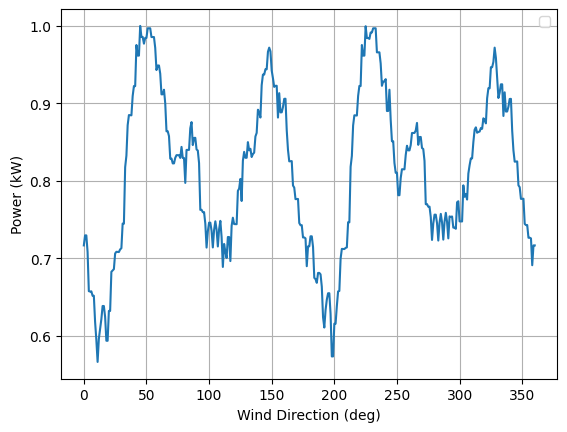

In [53]:
fi_powers_nrel.reinitialize(layout_x=df_nrel['Layout_x'], layout_y=df_nrel['Layout_y'])

wd_array = np.arange(0,361,1.)
fi_powers_nrel.reinitialize(wind_directions=wd_array)

num_wd = len(wd_array) # Number of wind directions
num_ws = 1 # Number of wind speeds
num_turbine = len(df_nrel['Layout_x']) #  Number of turbines
yaw_angles = np.zeros((num_wd, num_ws, num_turbine))

# Calculate
fi_powers_nrel.calculate_wake(yaw_angles=yaw_angles)

# Collect the turbine powers
turbine_powers = fi_powers_nrel.get_turbine_powers() / 1E3 # In kW

# Pull out the power values per turbine
pow_t0 = turbine_powers[:,:,0].flatten()
pow_t1 = turbine_powers[:,:,1].flatten()
pow_t2 = turbine_powers[:,:,2].flatten()
pow_t3 = turbine_powers[:,:,3].flatten()
pow_t4 = turbine_powers[:,:,4].flatten()
pow_t5 = turbine_powers[:,:,5].flatten()
pow_t6 = turbine_powers[:,:,6].flatten()
# pow_t7 = turbine_powers[:,:,7].flatten()
pow_avrg = np.mean(turbine_powers, axis=2).flatten()
pow_avrg_normalized = pow_avrg / np.max(pow_avrg)
# Plot
fig, ax = plt.subplots()
ax.plot(wd_array,pow_avrg_normalized)
# ax.plot(wd_array,pow_t1,color='r',label='T2')
# ax.plot(wd_array,pow_t2,color='b',label='T3')
# ax.plot(wd_array,pow_t3,color='g',label='T4')
# ax.plot(wd_array,pow_t4,color='c',label='T5')
# ax.plot(wd_array,pow_t5,color='m',label='T6')
# ax.plot(wd_array,pow_t6,color='y',label='T7')
ax.grid(True)
ax.legend()
ax.set_xlabel('Wind Direction (deg)')
ax.set_ylabel('Power (kW)')

plt.show()

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


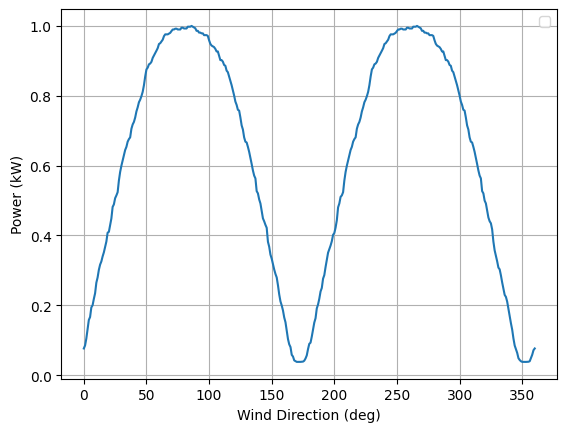

In [52]:
fi_powers_vestas.reinitialize(layout_x=df_vestas['Layout_x'], layout_y=df_vestas['Layout_y'])

wd_array = np.arange(0,361,1.)
fi_powers_vestas.reinitialize(wind_directions=wd_array)

num_wd = len(wd_array) # Number of wind directions
num_ws = 1 # Number of wind speeds
num_turbine = len(df_vestas['Layout_x']) #  Number of turbines
yaw_angles = np.zeros((num_wd, num_ws, num_turbine))

# Calculate
fi_powers_vestas.calculate_wake(yaw_angles=yaw_angles)

# Collect the turbine powers
turbine_powers_v = fi_powers_vestas.get_turbine_powers() / 1E3 # In kW


pow_avrg_v = np.mean(turbine_powers_v, axis=2).flatten()
pow_avrg_normalized_v = pow_avrg_v / np.max(pow_avrg_v)
# Plot
fig, ax = plt.subplots()
ax.plot(wd_array,pow_avrg_normalized_v)

ax.grid(True)
ax.legend()
ax.set_xlabel('Wind Direction (deg)')
ax.set_ylabel('Power (kW)')

plt.show()

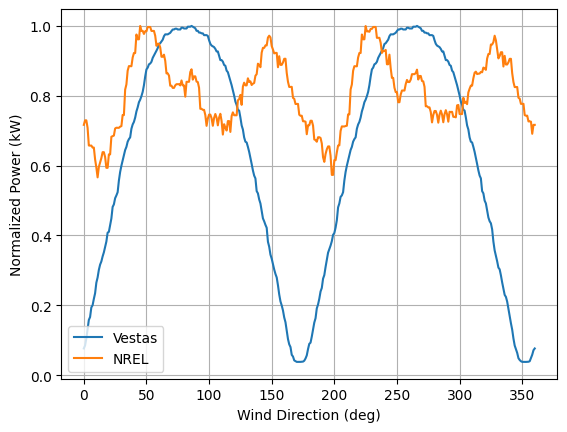

In [54]:
fig, ax = plt.subplots()
ax.plot(wd_array,pow_avrg_normalized_v, label='Vestas')
ax.plot(wd_array,pow_avrg_normalized, label='NREL')

ax.grid(True)
ax.legend()
ax.set_xlabel('Wind Direction (deg)')
ax.set_ylabel('Normalized Power (kW)')

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


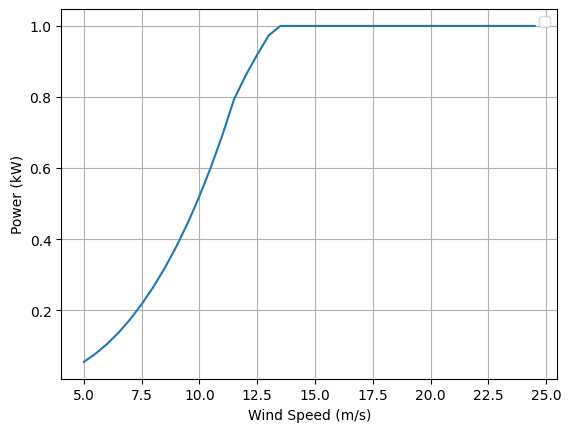

In [41]:
fi_powers_nrel.reinitialize(layout_x=df_nrel['Layout_x'], layout_y=df_nrel['Layout_y'])

# Sweep wind speeds but keep wind direction fi_powers_nrelxed
ws_array = np.arange(5,25,0.5)
fi_powers_nrel.reinitialize(wind_speeds=ws_array)

# Defi_powers_nrelne a matrix of yaw angles to be all 0
# Note that yaw angles is now specifi_powers_nreled as a matrix whose dimesions are
# wd/ws/turbine
num_wd = 1
num_ws = len(ws_array)
num_turbine = len(df_nrel['Layout_x'])
yaw_angles = np.zeros((num_wd, num_ws, num_turbine))

# Calculate
fi_powers_nrel.calculate_wake(yaw_angles=yaw_angles)

# Collect the turbine powers
turbine_powers_s = fi_powers_nrel.get_turbine_powers() / 1E3 # In kW


pow_avrg_s = np.mean(turbine_powers_s, axis=2).flatten()
pow_avrg_normalized_s = pow_avrg_s / np.max(pow_avrg_s)

# Plot
fig, ax = plt.subplots()
ax.plot(ws_array,pow_avrg_normalized_s)
ax.grid(True)
ax.legend()
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


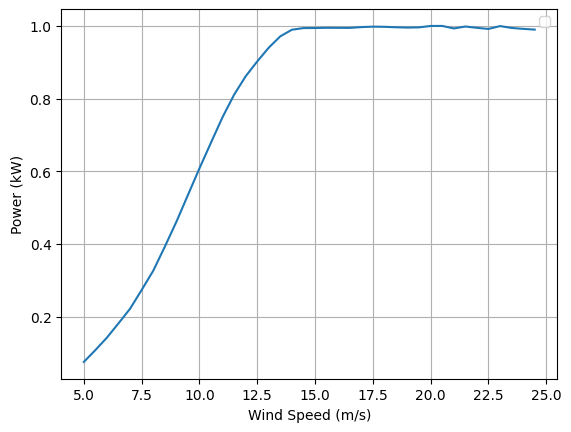

In [45]:
fi_powers_vestas.reinitialize(layout_x=df_vestas['Layout_x'], layout_y=df_vestas['Layout_y'])

# Sweep wind speeds but keep wind direction fi_powers_vestasxed
ws_array = np.arange(5,25,0.5)
fi_powers_vestas.reinitialize(wind_speeds=ws_array)

# Defi_powers_vestasne a matrix of yaw angles to be all 0
# Note that yaw angles is now specifi_powers_vestased as a matrix whose dimesions are
# wd/ws/turbine
num_wd = 1
num_ws = len(ws_array)
num_turbine = len(df_vestas['Layout_x'])
yaw_angles = np.zeros((num_wd, num_ws, num_turbine))

# Calculate
fi_powers_vestas.calculate_wake(yaw_angles=yaw_angles)

# Collect the turbine powers
turbine_powers_vs = fi_powers_vestas.get_turbine_powers() / 1E3 # In kW


pow_avrg_vs = np.mean(turbine_powers_vs, axis=2).flatten()
pow_avrg_normalized_vs = pow_avrg_vs / np.max(pow_avrg_vs)

# Plot
fig, ax = plt.subplots()
ax.plot(ws_array,pow_avrg_normalized_vs)
ax.grid(True)
ax.legend()
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (kW)')
plt.show()

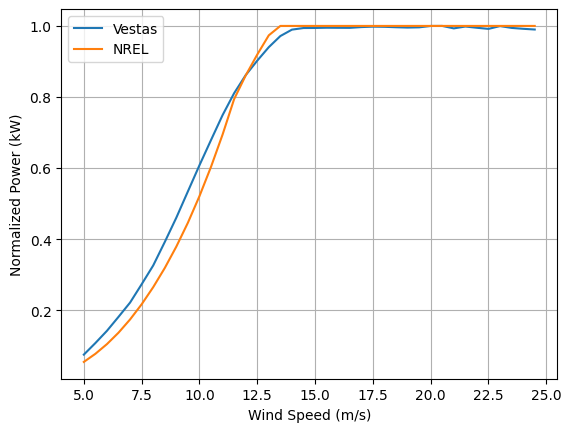

In [47]:
fig, ax = plt.subplots()
ax.plot(ws_array,pow_avrg_normalized_vs, label='Vestas')
ax.plot(ws_array,pow_avrg_normalized_s, label='NREL')
ax.grid(True)
ax.legend()
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Normalized Power (kW)')
plt.show()

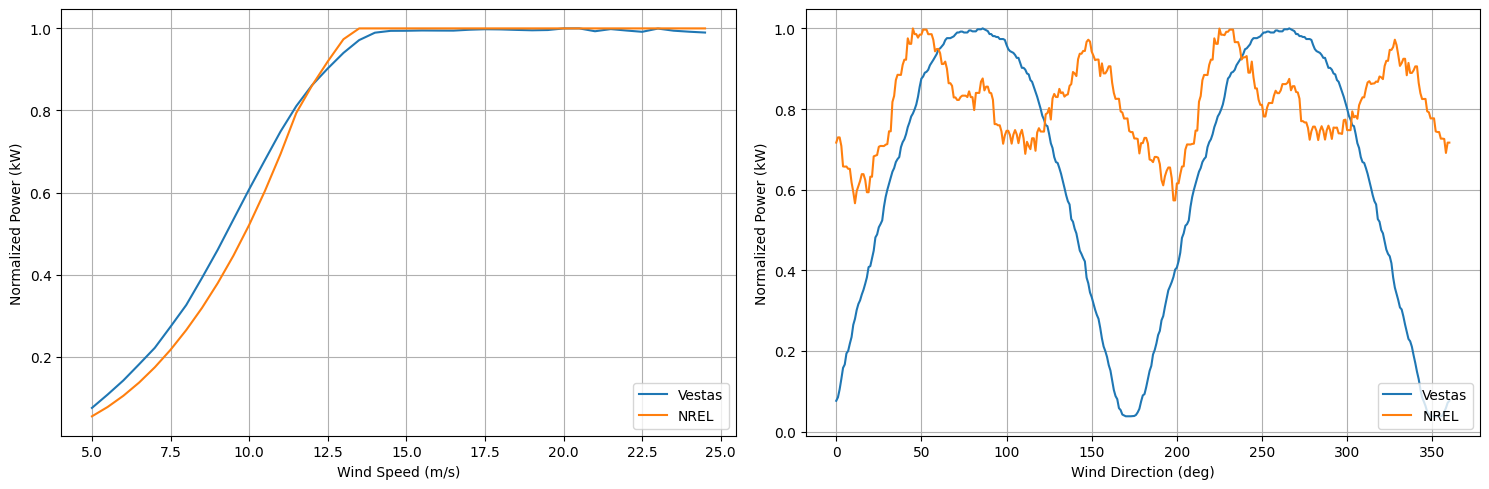

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plot the Vestas and NREL data on the first subplot
axs[0].plot(ws_array, pow_avrg_normalized_vs, label='Vestas')
axs[0].plot(ws_array, pow_avrg_normalized_s, label='NREL')
axs[0].grid(True)
axs[0].legend(loc='lower right')
axs[0].set_xlabel('Wind Speed (m/s)')
axs[0].set_ylabel('Normalized Power (kW)')

# Plot the Vestas and NREL data on the second subplot
axs[1].plot(wd_array, pow_avrg_normalized_v, label='Vestas')
axs[1].plot(wd_array, pow_avrg_normalized, label='NREL')
axs[1].grid(True)
axs[1].legend(loc='lower right')
axs[1].set_xlabel('Wind Direction (deg)')
axs[1].set_ylabel('Normalized Power (kW)')

plt.tight_layout()
plt.show()